## VinDr ChestXRay

Análise exploratória dos arquivos `image_labels_test.csv` e `image_labels_train.csv`.

In [2]:
from pathlib import Path

import ast
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

ModuleNotFoundError: No module named 'seaborn'

In [3]:
base_path = Path('data/vindrxray')
train_path = base_path / 'image_labels_train.csv'
test_path = base_path / 'image_labels_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
train_df['split'] = 'train'
test_df['split'] = 'test'
all_df = pd.concat([train_df, test_df], ignore_index=True)

display(train_df.head())
display(test_df.head())


,image_id,rad_ID,No finding,Bronchitis,Brocho-pneumonia,Other disease,Bronchiolitis,Situs inversus,Pneumonia,Pleuro-pneumonia,Diagphramatic hernia,Tuberculosis,Congenital emphysema,CPAM,Hyaline membrane disease,Mediastinal tumor,Lung tumor,split
0,6cb53aff85c71b98ad13d67a131708c6,R3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
1,40414c05687cdb156823c156967b13f0,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
2,0e4a464dfbf8abc6333c82f1b77b6455,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
3,f4d3fab0b71381e6b237dc36301e85a0,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
4,b58c9b1c89978a0b1f8533b7a2ca1088,R3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train


,image_id,rad_ID,No finding,Bronchitis,Brocho-pneumonia,Other disease,Bronchiolitis,Situs inversus,Pneumonia,Pleuro-pneumonia,Diagphramatic hernia,Tuberculosis,Congenital emphysema,CPAM,Hyaline membrane disease,Mediastinal tumor,Lung tumor,split
0,d7e71a052a753c3f2f3e317d60177bec,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test
1,e64d9421e78c82b5c104021a6c1b4e67,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test
2,8a12a4352a866aaea4691dd27a99c7ae,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test
3,30d6a0843a9792168fdc456c17a9028c,R3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test
4,f22138be08a24e79cf07f6207341e5f5,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,test


### Analisar se existem imagens repetidas

In [6]:
train_df["image_id"].duplicated().any()

np.False_

In [7]:
test_df["image_id"].duplicated().any()

np.False_

In [8]:
train_ids = set(train_df["image_id"])
test_ids = set(test_df["image_id"])

duplicados = train_ids.intersection(test_ids)

print(len(duplicados))
print(duplicados)

0
set()


## Verificar se existem imagens com mais de uma classe

In [9]:
classes = all_df.columns.drop(
    ["image_id", "rad_ID", "rad_id", "split"],
    errors="ignore"
)

num_classes_por_imagem = all_df[classes].sum(axis=1)

imagens_multiclasse = all_df[num_classes_por_imagem > 1]

print(f"{len(imagens_multiclasse)} imagens possuem mais de uma classe")

264 imagens possuem mais de uma classe


In [10]:
num_classes_por_imagem.value_counts().sort_index()

0.0      64
1.0    8797
2.0     257
3.0       6
4.0       1
Name: count, dtype: int64

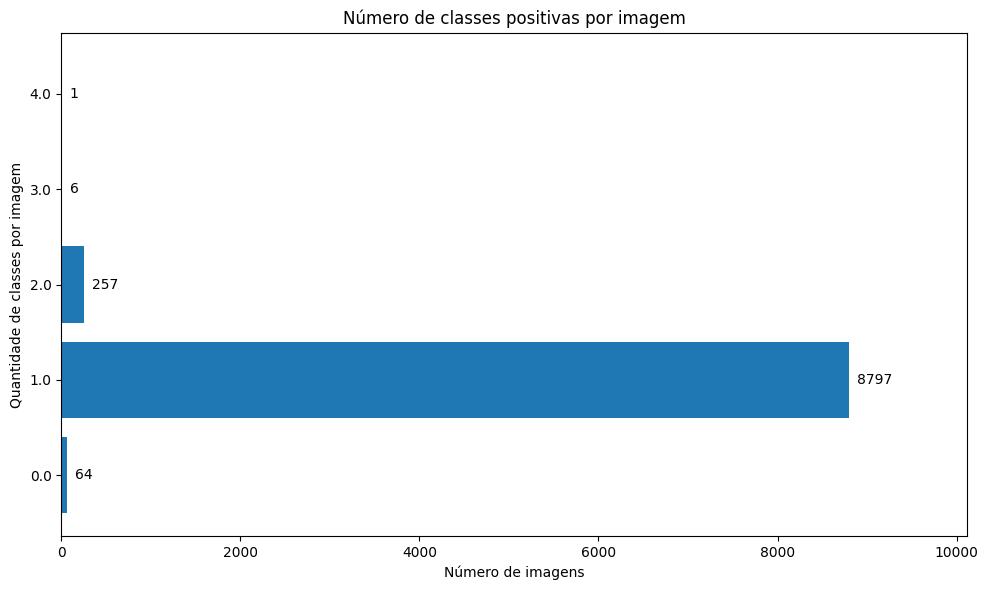

In [11]:
classes = all_df.columns.drop(
    ["image_id", "rad_ID", "rad_id", "split"],
    errors="ignore"
)

num_classes_por_imagem = all_df[classes].sum(axis=1)

dist = num_classes_por_imagem.value_counts().sort_index()

plt.figure(figsize=(10, 6))

bars = plt.barh(dist.index.astype(str), dist.values)

plt.title("Número de classes positivas por imagem")
plt.xlabel("Número de imagens")
plt.ylabel("Quantidade de classes por imagem")

plt.xlim(0, max(dist.values) * 1.15)

for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + max(dist.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(int(largura)),
        va="center"
    )

plt.tight_layout()
plt.show()

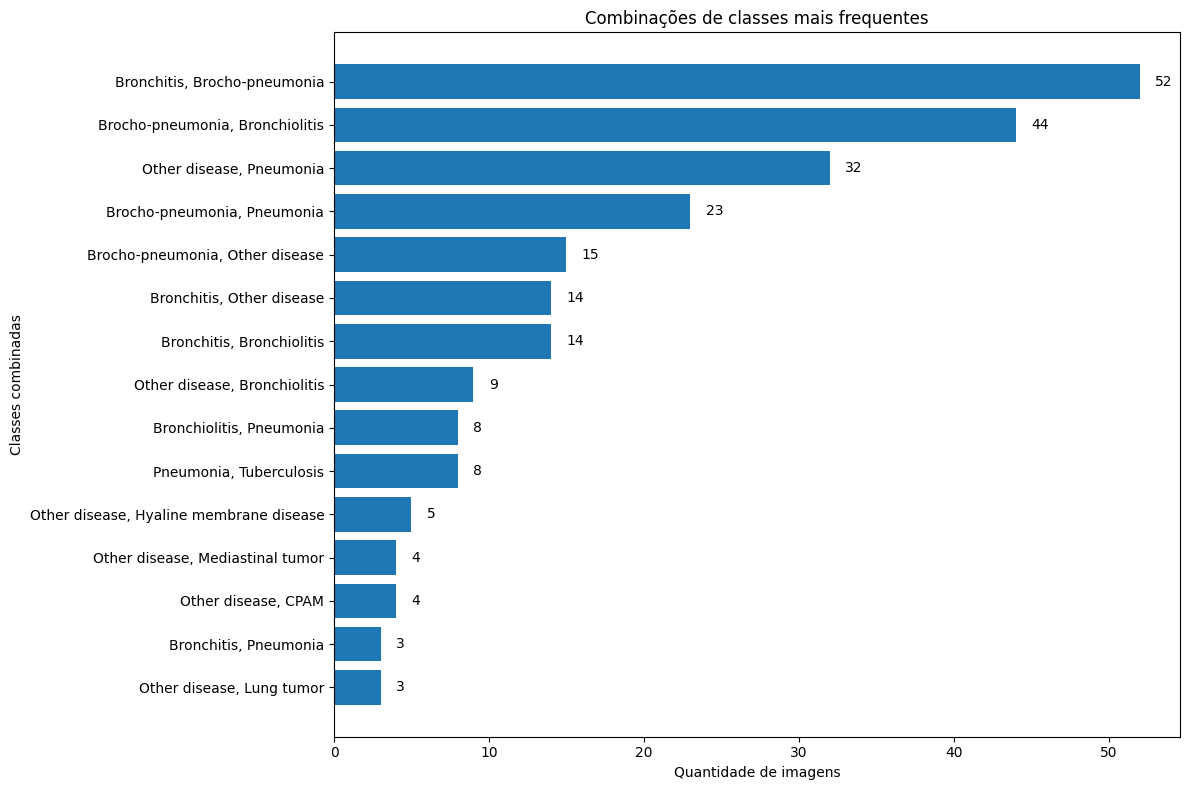

In [12]:
classes = all_df.columns.drop(
    ["image_id", "rad_ID", "rad_id", "split"],
    errors="ignore"
)

# Garante que as classes são numéricas
all_df[classes] = all_df[classes].apply(pd.to_numeric, errors="coerce").fillna(0)

# Para cada linha/imagem, pega as classes positivas
all_df["classes_positivas"] = all_df[classes].apply(
    lambda row: ", ".join(row.index[row == 1]),
    axis=1
)

# Remove imagens sem classe positiva
com_multiplas_classes = all_df[
    all_df["classes_positivas"].str.contains(",")
]

# Conta combinações repetidas
combinacoes = (
    com_multiplas_classes["classes_positivas"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 8))

bars = plt.barh(combinacoes.index, combinacoes.values)

plt.title("Combinações de classes mais frequentes")
plt.xlabel("Quantidade de imagens")
plt.ylabel("Classes combinadas")

plt.gca().invert_yaxis()

for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + 1,
        bar.get_y() + bar.get_height() / 2,
        str(int(largura)),
        va="center"
    )

plt.tight_layout()
plt.show()

# Treino

### Analisar quantas classes existem

In [13]:
print(train_df.columns.tolist())

['image_id', 'rad_ID', 'No finding', 'Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor', 'split']


In [14]:
classes = train_df.columns.drop(["image_id", "rad_ID", "rad_id", "split"], errors="ignore")

train_df[classes] = train_df[classes].apply(pd.to_numeric, errors="coerce")

contagem_classes_train = train_df[classes].sum().sort_values(ascending=False)

contagem_classes_train_df = contagem_classes_train.reset_index()
contagem_classes_train_df.columns = ["Classe", "Quantidade"]

contagem_classes_train_df["Porcentagem (%)"] = (
    contagem_classes_train_df["Quantidade"] / len(train_df) * 100
).round(2)

display(contagem_classes_train_df)

,Classe,Quantidade,Porcentagem (%)
0,No finding,5143.0,66.55
1,Bronchitis,842.0,10.90
2,Brocho-pneumonia,545.0,7.05
3,Bronchiolitis,497.0,6.43
4,Other disease,412.0,5.33
5,Pneumonia,392.0,5.07
6,Hyaline membrane disease,19.0,0.25
7,Tuberculosis,14.0,0.18
8,Situs inversus,11.0,0.14
9,Mediastinal tumor,8.0,0.10


In [15]:
print("Quantidade de classes:", len(classes))

Quantidade de classes: 15


## Gráficos

### Distribuição das classes por quantidade

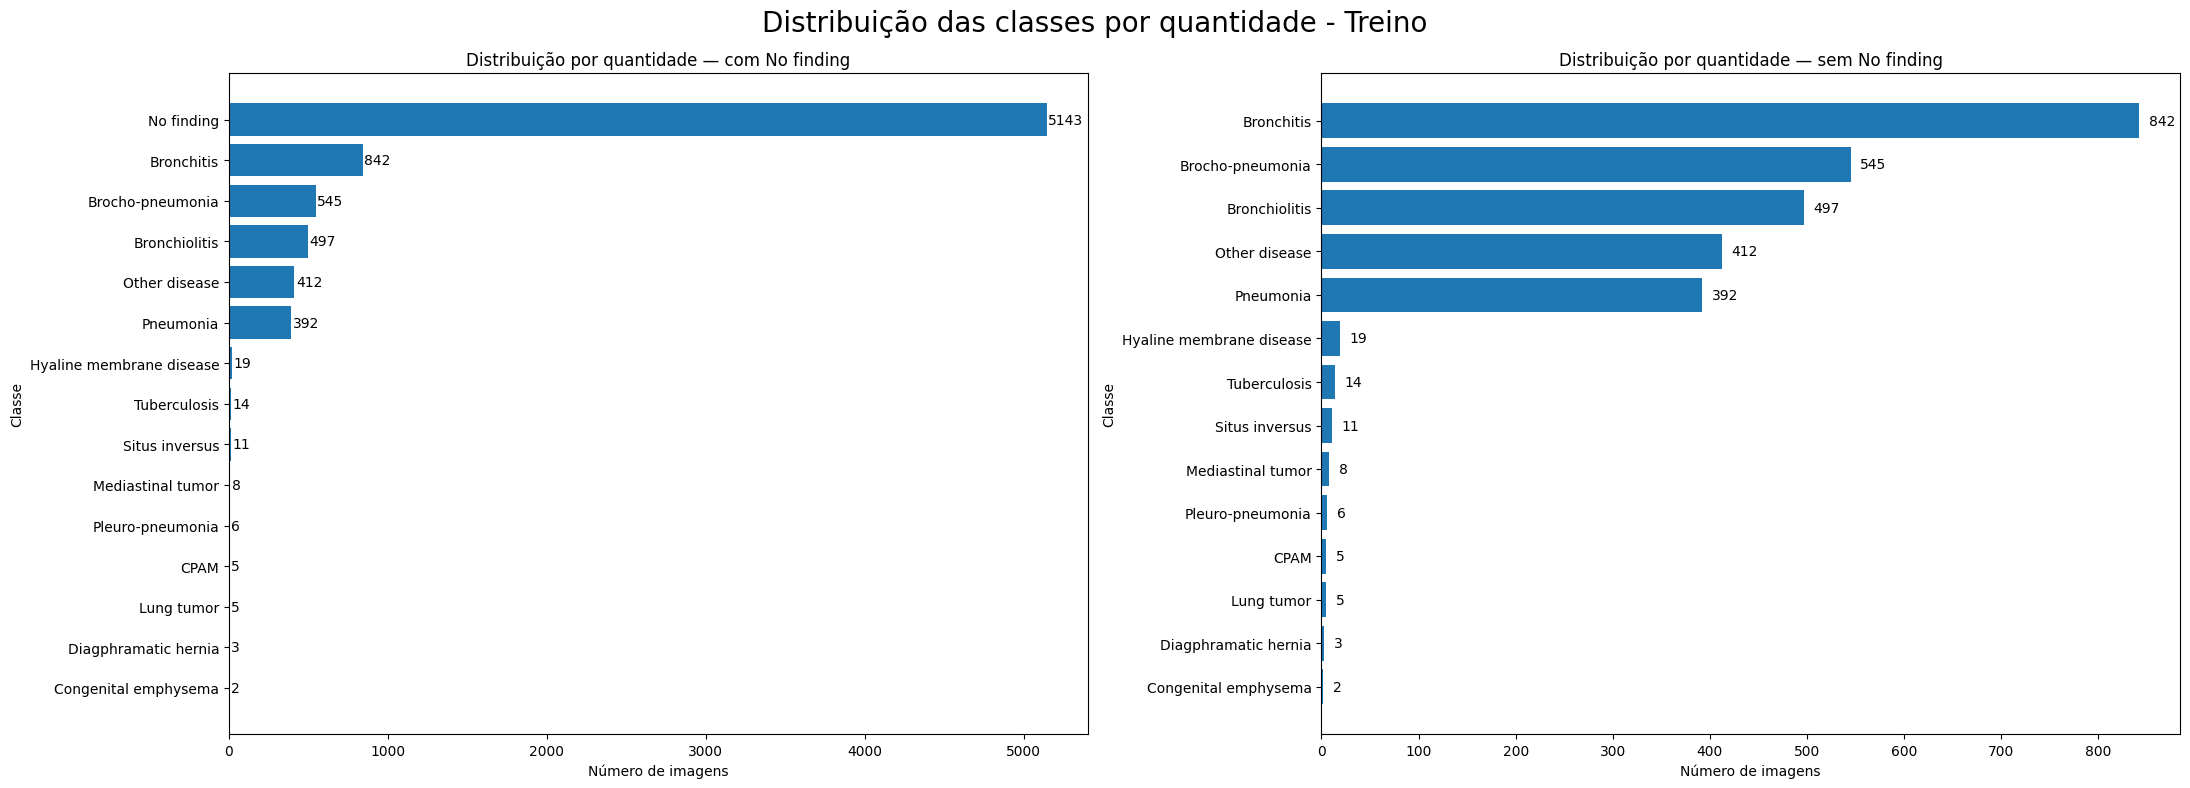

In [16]:
df_com_no_finding_train = contagem_classes_train_df.sort_values(by="Quantidade", ascending=False)

df_sem_no_finding_train = contagem_classes_train_df[
    contagem_classes_train_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Com No finding
bars1 = axes[0].barh(df_com_no_finding_train["Classe"], df_com_no_finding_train["Quantidade"])
axes[0].set_title("Distribuição por quantidade — com No finding")
axes[0].set_xlabel("Número de imagens")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

# Sem No finding
bars2 = axes[1].barh(df_sem_no_finding_train["Classe"], df_sem_no_finding_train["Quantidade"])
axes[1].set_title("Distribuição por quantidade — sem No finding")
axes[1].set_xlabel("Número de imagens")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

plt.suptitle("Distribuição das classes por quantidade - Treino", fontsize=20)
plt.tight_layout()
plt.show()

### Distribuição percentual das classes

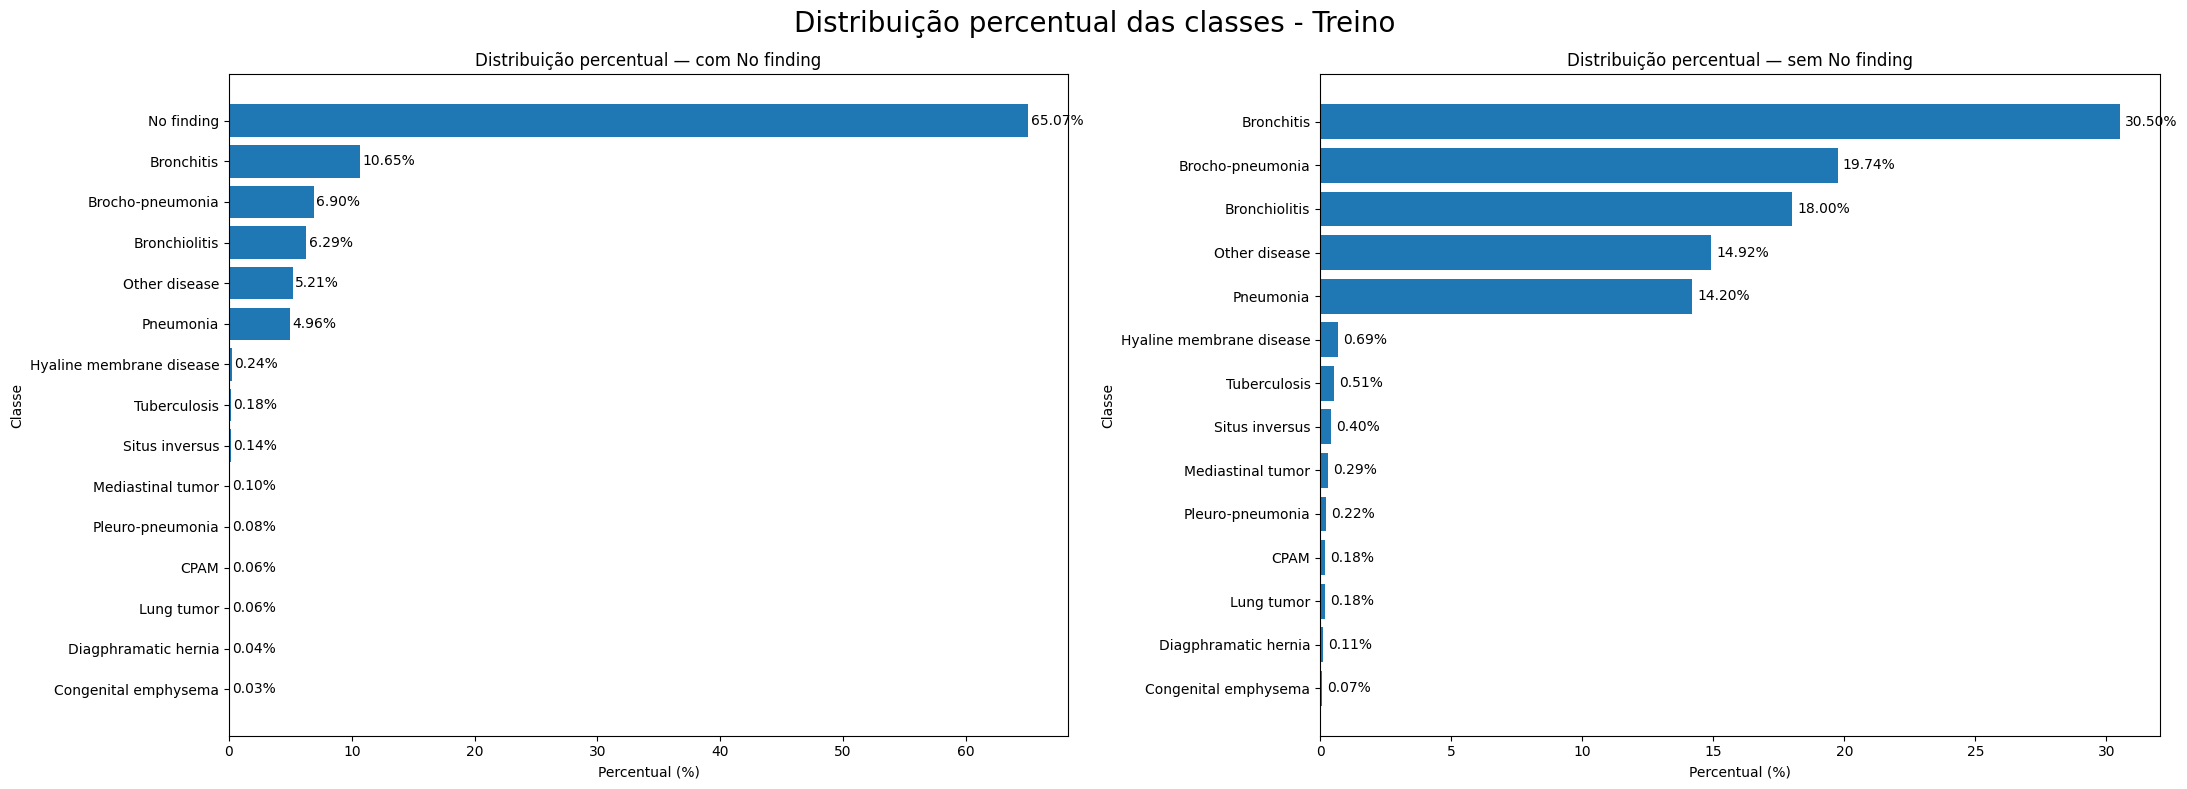

In [17]:
df_com_no_finding_train = contagem_classes_train_df.sort_values(by="Quantidade", ascending=False).copy()

df_sem_no_finding_train = contagem_classes_train_df[
    contagem_classes_train_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False).copy()

# Percentual considerando o total com No finding
df_com_no_finding_train["Percentual (%)"] = (
    df_com_no_finding_train["Quantidade"] / df_com_no_finding_train["Quantidade"].sum() * 100
).round(2)

# Percentual recalculado excluindo No finding
df_sem_no_finding_train["Percentual (%)"] = (
    df_sem_no_finding_train["Quantidade"] / df_sem_no_finding_train["Quantidade"].sum() * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Percentual com No finding
bars1 = axes[0].barh(df_com_no_finding_train["Classe"], df_com_no_finding_train["Percentual (%)"])
axes[0].set_title("Distribuição percentual — com No finding")
axes[0].set_xlabel("Percentual (%)")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

# Percentual sem No finding
bars2 = axes[1].barh(df_sem_no_finding_train["Classe"], df_sem_no_finding_train["Percentual (%)"])
axes[1].set_title("Distribuição percentual — sem No finding")
axes[1].set_xlabel("Percentual (%)")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

plt.suptitle("Distribuição percentual das classes - Treino", fontsize=20)
plt.tight_layout()
plt.show()

# Teste

### Analisar quantas classes existem

In [18]:
print(test_df.columns.tolist())

['image_id', 'rad_ID', 'No finding', 'Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor', 'split']


In [19]:
print("Quantidade de classes:", len(classes))

Quantidade de classes: 15


In [20]:
classes = test_df.columns.drop(["image_id", "rad_ID", "rad_id", "split"], errors="ignore")

test_df[classes] = test_df[classes].apply(pd.to_numeric, errors="coerce")

contagem_classes_test = test_df[classes].sum().sort_values(ascending=False)

contagem_classes_test_df = contagem_classes_test.reset_index()
contagem_classes_test_df.columns = ["Classe", "Quantidade"]

contagem_classes_test_df["Porcentagem (%)"] = (
    contagem_classes_test_df["Quantidade"] / len(test_df) * 100
).round(2)

display(contagem_classes_test_df)

,Classe,Quantidade,Porcentagem (%)
0,No finding,907.0,64.92
1,Bronchitis,174.0,12.46
2,Bronchiolitis,90.0,6.44
3,Pneumonia,89.0,6.37
4,Brocho-pneumonia,84.0,6.01
5,Other disease,77.0,5.51
6,Hyaline membrane disease,3.0,0.21
7,Situs inversus,2.0,0.14
8,Tuberculosis,1.0,0.07
9,CPAM,1.0,0.07


### Distribuição das classes por quantidade

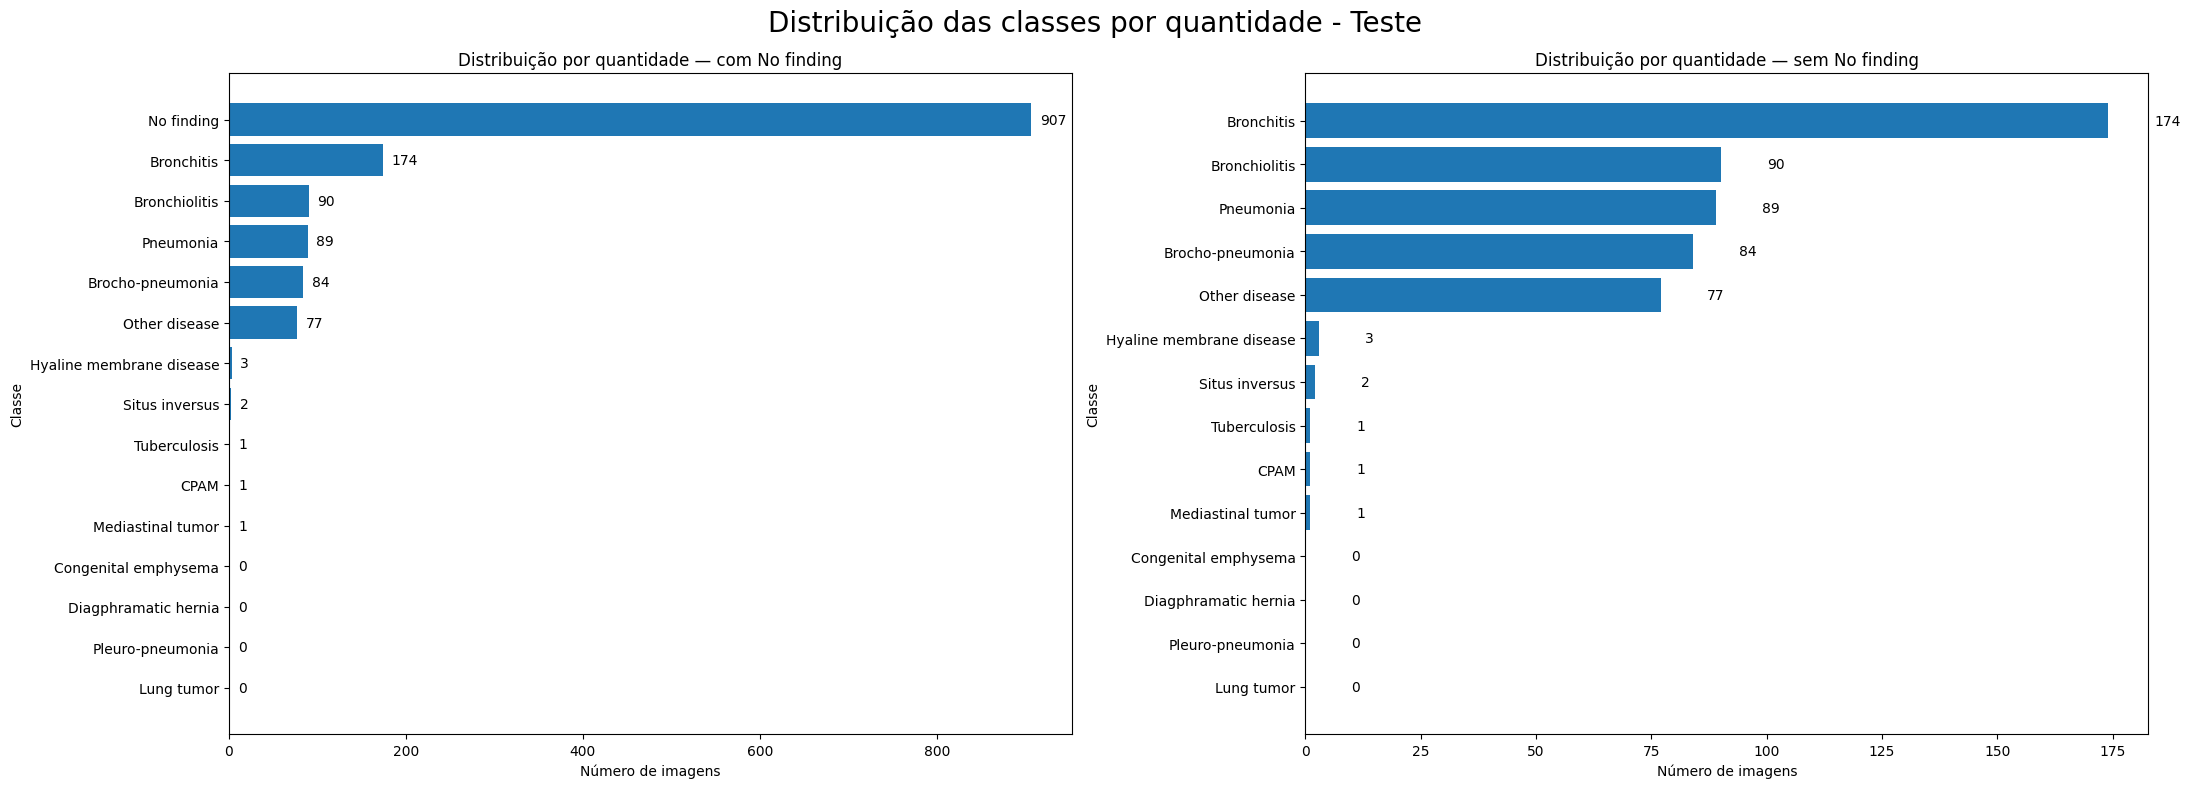

In [21]:
df_com_no_finding_test = contagem_classes_test_df.sort_values(by="Quantidade", ascending=False)

df_sem_no_finding_test = contagem_classes_test_df[
    contagem_classes_test_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Com No finding
bars1 = axes[0].barh(df_com_no_finding_test["Classe"], df_com_no_finding_test["Quantidade"])
axes[0].set_title("Distribuição por quantidade — com No finding")
axes[0].set_xlabel("Número de imagens")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

# Sem No finding
bars2 = axes[1].barh(df_sem_no_finding_test["Classe"], df_sem_no_finding_test["Quantidade"])
axes[1].set_title("Distribuição por quantidade — sem No finding")
axes[1].set_xlabel("Número de imagens")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

plt.suptitle("Distribuição das classes por quantidade - Teste", fontsize=20)
plt.tight_layout()
plt.show()

### Distribuição percentual das classes

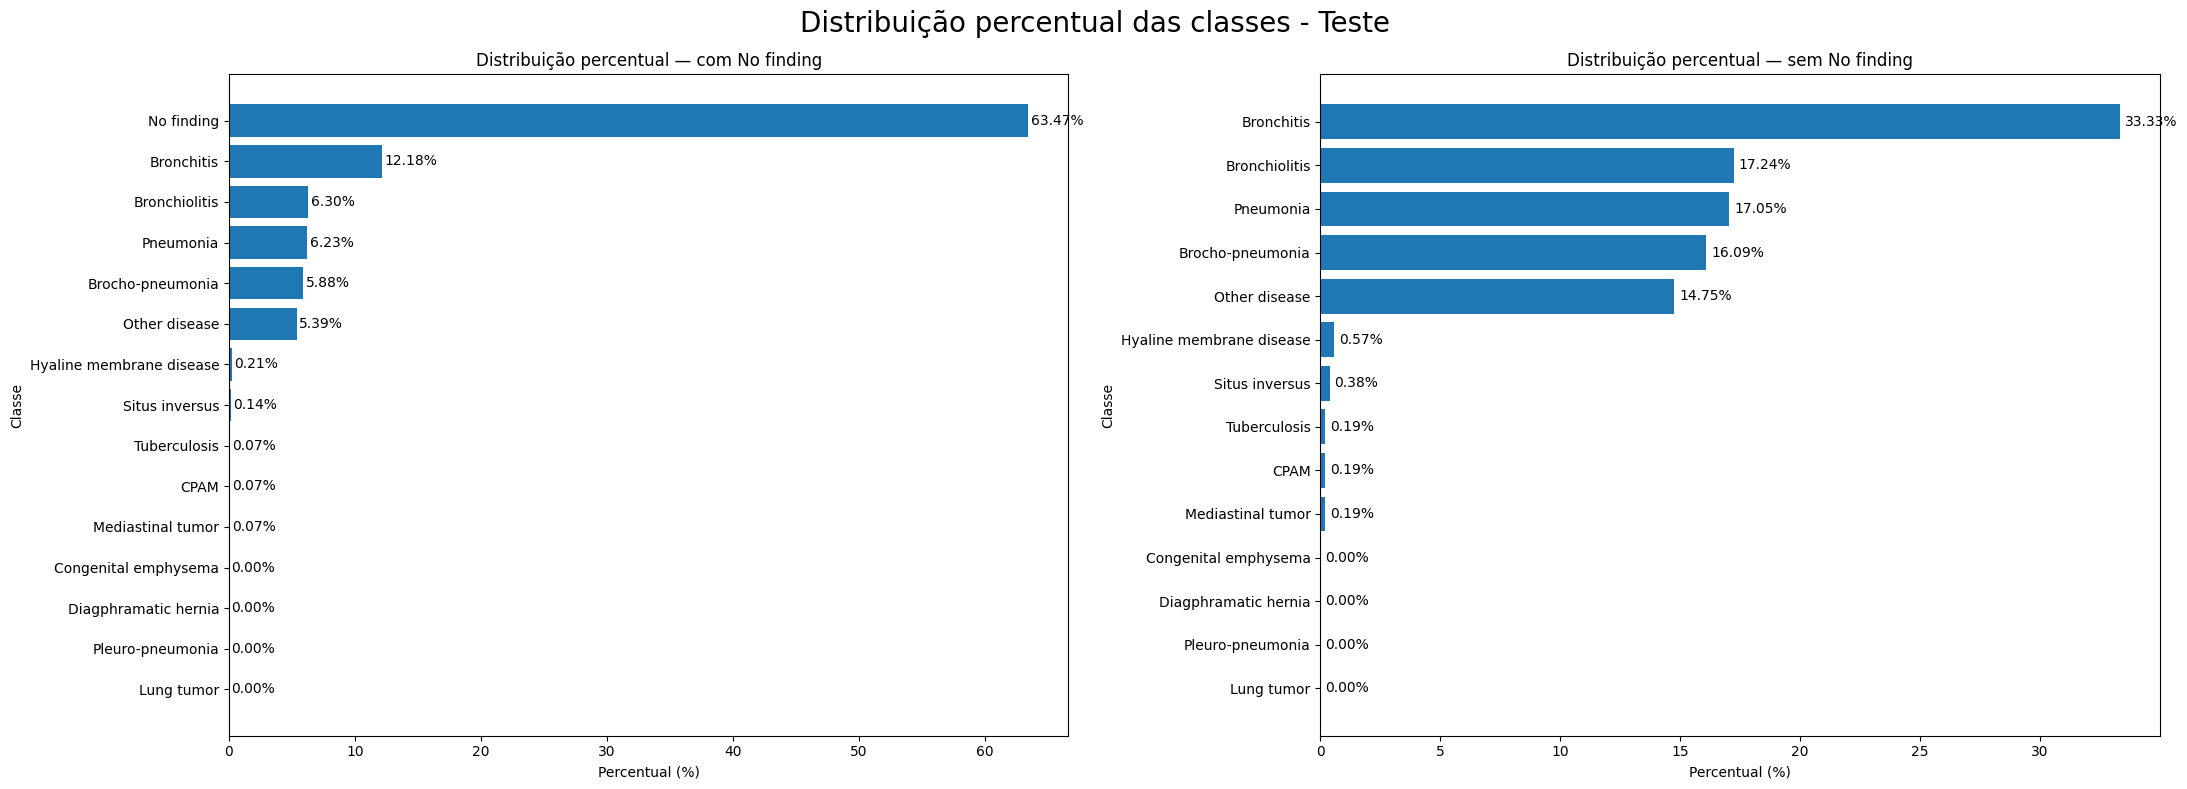

In [22]:
df_com_no_finding_test = contagem_classes_test_df.sort_values(by="Quantidade", ascending=False).copy()

df_sem_no_finding_test = contagem_classes_test_df[
    contagem_classes_test_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False).copy()

# Percentual considerando o total com No finding
df_com_no_finding_test["Percentual (%)"] = (
    df_com_no_finding_test["Quantidade"] / df_com_no_finding_test["Quantidade"].sum() * 100
).round(2)

# Percentual recalculado excluindo No finding
df_sem_no_finding_test["Percentual (%)"] = (
    df_sem_no_finding_test["Quantidade"] / df_sem_no_finding_test["Quantidade"].sum() * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Percentual com No finding
bars1 = axes[0].barh(df_com_no_finding_test["Classe"], df_com_no_finding_test["Percentual (%)"])
axes[0].set_title("Distribuição percentual — com No finding")
axes[0].set_xlabel("Percentual (%)")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

# Percentual sem No finding
bars2 = axes[1].barh(df_sem_no_finding_test["Classe"], df_sem_no_finding_test["Percentual (%)"])
axes[1].set_title("Distribuição percentual — sem No finding")
axes[1].set_xlabel("Percentual (%)")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

plt.suptitle("Distribuição percentual das classes - Teste", fontsize=20)
plt.tight_layout()
plt.show()

# Treino e teste

### Analisar quantas classes existem

In [23]:
classes = all_df.columns.drop(["image_id", "rad_ID", "rad_id", "split"], errors="ignore")

all_df[classes] = all_df[classes].apply(pd.to_numeric, errors="coerce")

contagem_classes_all = all_df[classes].sum().sort_values(ascending=False)

contagem_classes_all_df = contagem_classes_all.reset_index()
contagem_classes_all_df.columns = ["Classe", "Quantidade"]

contagem_classes_all_df["Porcentagem (%)"] = (
    contagem_classes_all_df["Quantidade"] / len(all_df) * 100
).round(2)

display(contagem_classes_all_df)

,Classe,Quantidade,Porcentagem (%)
0,No finding,6050.0,66.30
1,Bronchitis,1016.0,11.13
2,Brocho-pneumonia,629.0,6.89
3,Bronchiolitis,587.0,6.43
4,Other disease,489.0,5.36
5,Pneumonia,481.0,5.27
6,Hyaline membrane disease,22.0,0.24
7,Tuberculosis,15.0,0.16
8,Situs inversus,13.0,0.14
9,Mediastinal tumor,9.0,0.10


### Distribuição das classes por quantidade

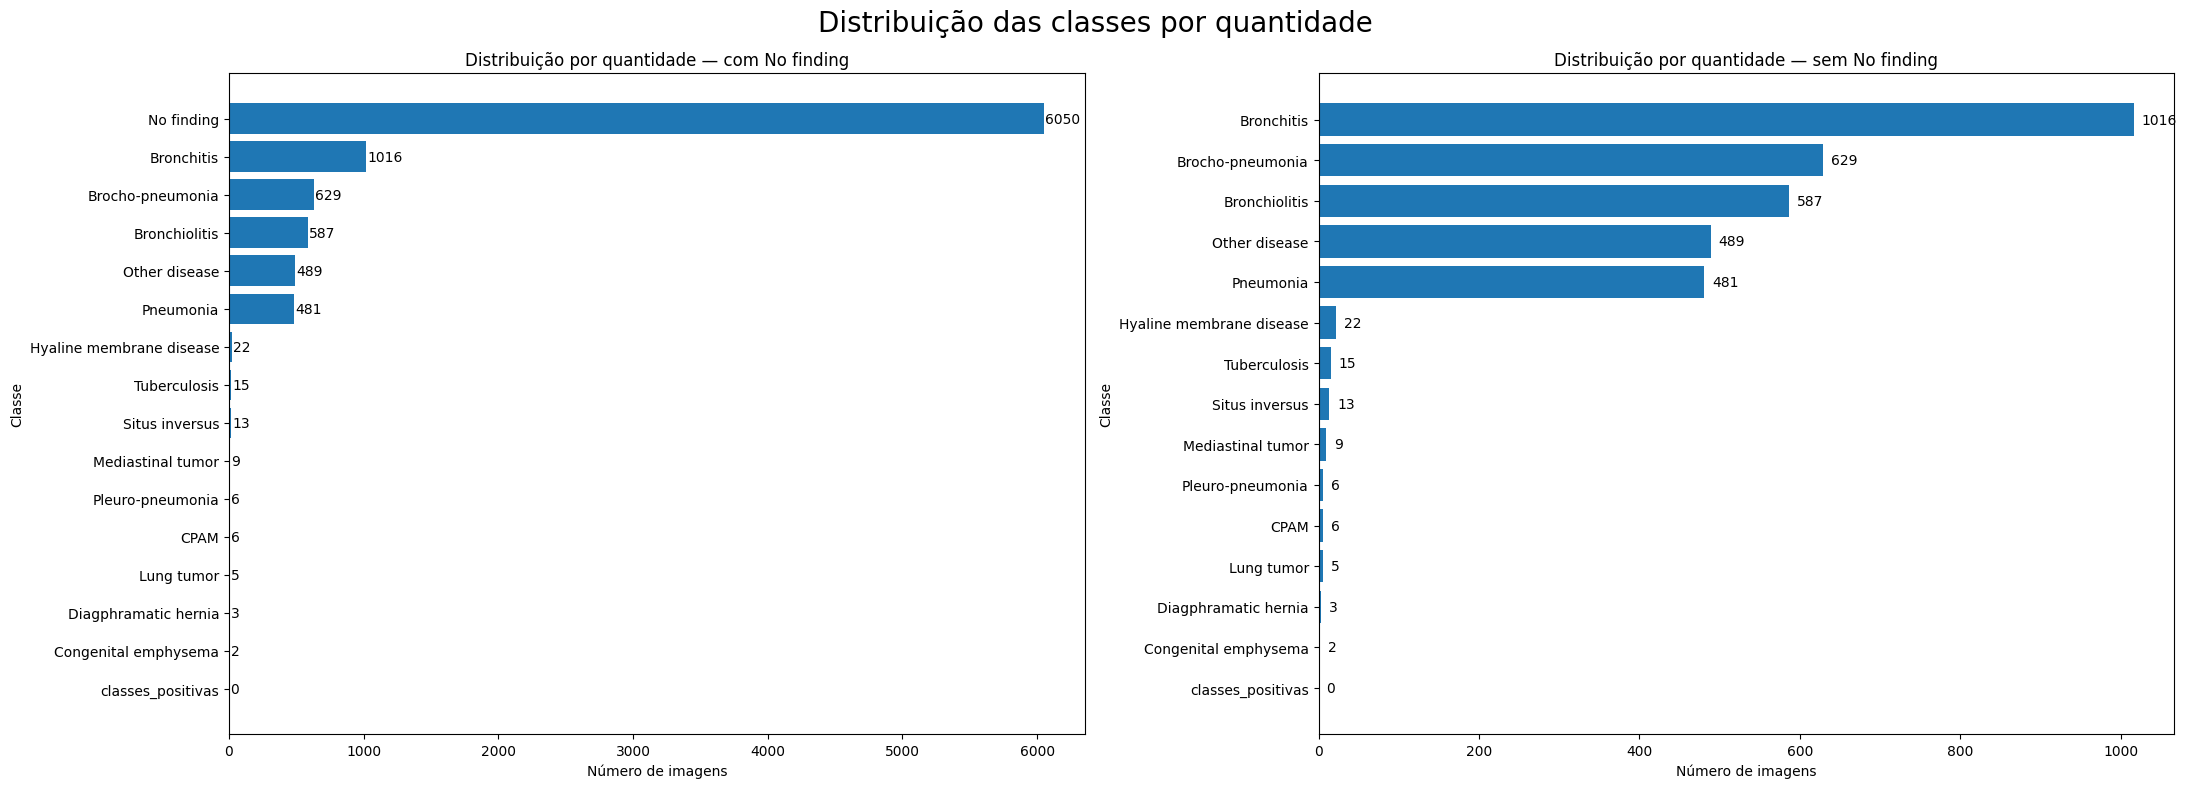

In [24]:
df_com_no_finding_all = contagem_classes_all_df.sort_values(by="Quantidade", ascending=False)

df_sem_no_finding_all = contagem_classes_all_df[
    contagem_classes_all_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Com No finding
bars1 = axes[0].barh(df_com_no_finding_all["Classe"], df_com_no_finding_all["Quantidade"])
axes[0].set_title("Distribuição por quantidade — com No finding")
axes[0].set_xlabel("Número de imagens")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

# Sem No finding
bars2 = axes[1].barh(df_sem_no_finding_all["Classe"], df_sem_no_finding_all["Quantidade"])
axes[1].set_title("Distribuição por quantidade — sem No finding")
axes[1].set_xlabel("Número de imagens")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 10, bar.get_y() + bar.get_height()/2, f"{int(valor)}", va="center")

plt.suptitle("Distribuição das classes por quantidade", fontsize=20)
plt.tight_layout()
plt.show()

### Distribuição percentual das classes

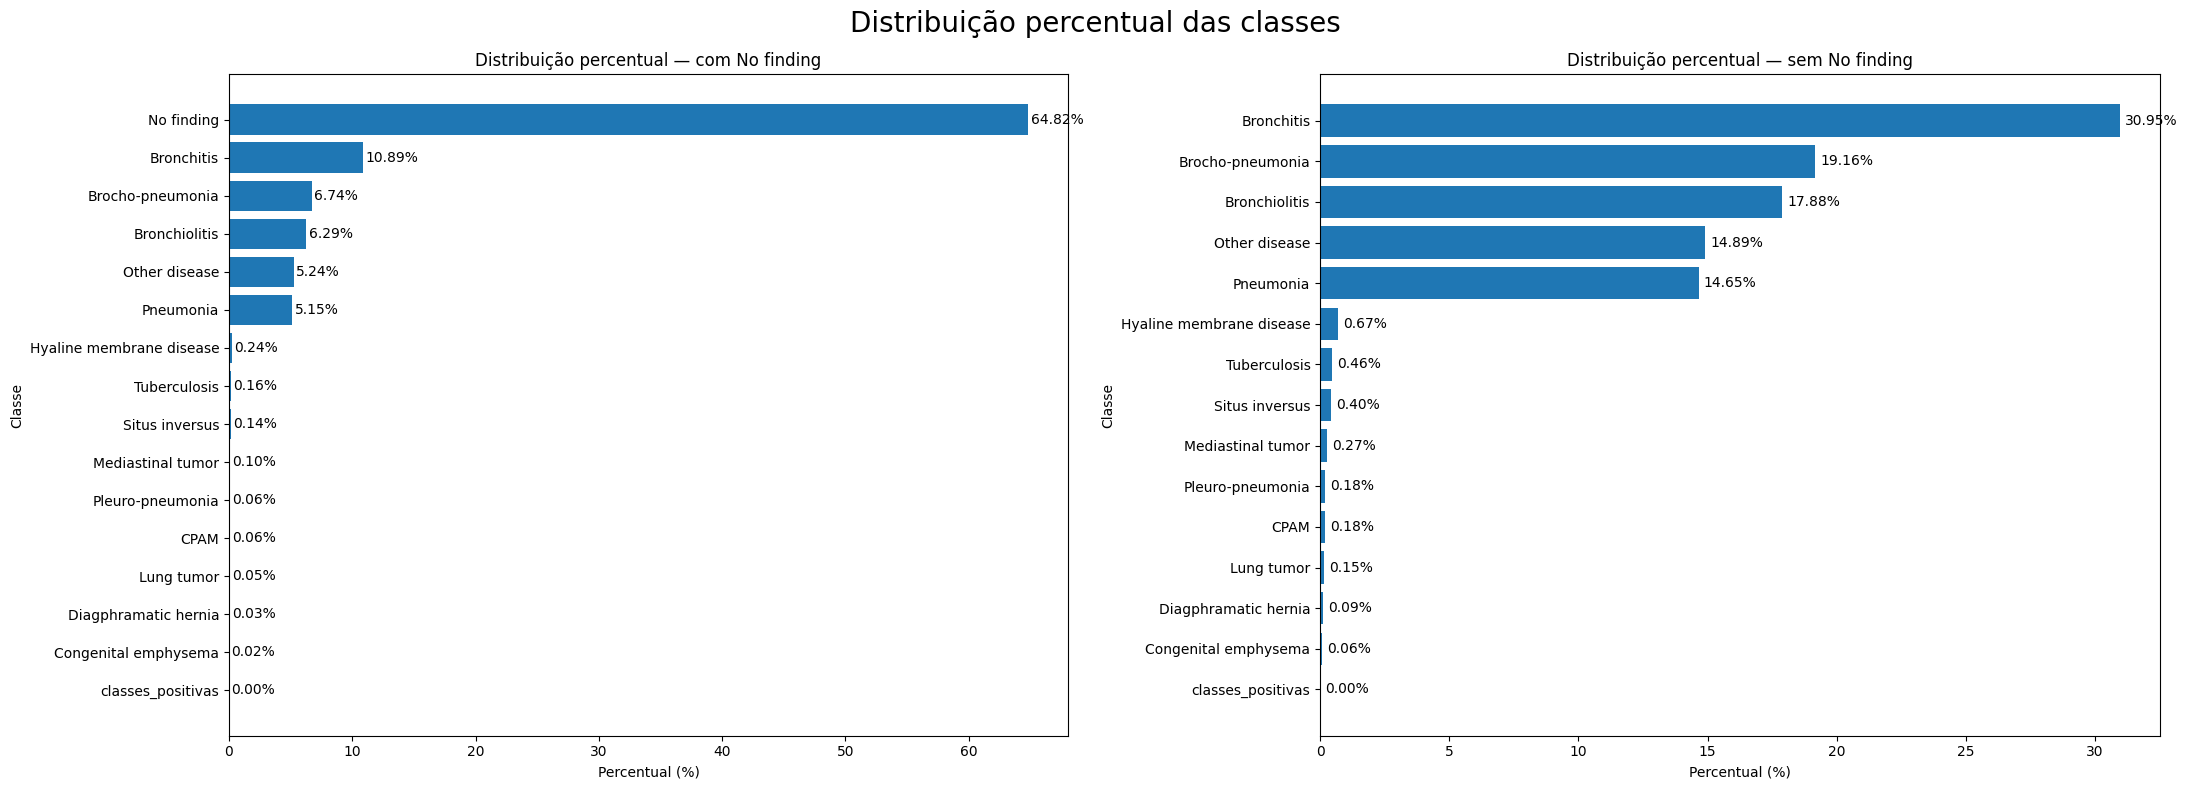

In [25]:
df_com_no_finding_all = contagem_classes_all_df.sort_values(by="Quantidade", ascending=False).copy()

df_sem_no_finding_all = contagem_classes_all_df[
    contagem_classes_all_df["Classe"] != "No finding"
].sort_values(by="Quantidade", ascending=False).copy()

# Percentual considerando o total com No finding
df_com_no_finding_all["Percentual (%)"] = (
    df_com_no_finding_all["Quantidade"] / df_com_no_finding_all["Quantidade"].sum() * 100
).round(2)

# Percentual recalculado excluindo No finding
df_sem_no_finding_all["Percentual (%)"] = (
    df_sem_no_finding_all["Quantidade"] / df_sem_no_finding_all["Quantidade"].sum() * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Percentual com No finding
bars1 = axes[0].barh(df_com_no_finding_all["Classe"], df_com_no_finding_all["Percentual (%)"])
axes[0].set_title("Distribuição percentual — com No finding")
axes[0].set_xlabel("Percentual (%)")
axes[0].set_ylabel("Classe")
axes[0].invert_yaxis()

for bar in bars1:
    valor = bar.get_width()
    axes[0].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

# Percentual sem No finding
bars2 = axes[1].barh(df_sem_no_finding_all["Classe"], df_sem_no_finding_all["Percentual (%)"])
axes[1].set_title("Distribuição percentual — sem No finding")
axes[1].set_xlabel("Percentual (%)")
axes[1].set_ylabel("Classe")
axes[1].invert_yaxis()

for bar in bars2:
    valor = bar.get_width()
    axes[1].text(valor + 0.2, bar.get_y() + bar.get_height()/2, f"{valor:.2f}%", va="center")

plt.suptitle("Distribuição percentual das classes", fontsize=20)
plt.tight_layout()
plt.show()

## Proporção

In [33]:
split_counts = all_df.groupby("split")["image_id"].nunique()

total = split_counts.sum()

resultado = pd.DataFrame({
    "Quantidade": split_counts,
    "Porcentagem (%)": (split_counts / total * 100).round(2)
})

# adiciona linha total
resultado.loc["TOTAL"] = [total, 100.00]

display(resultado)

,Quantidade,Porcentagem (%)
split,,
test,1397.0,15.31
train,7728.0,84.69
TOTAL,9125.0,100.00
